In [3]:
import os
from dotenv import load_dotenv
from openai import OpenAI


# .env파일을 업로드하여 사용합니다.
load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI()

In [2]:
import pandas as pd
from collections import Counter
import os

# 1) 데이터 로드
df = pd.read_csv("감기환자_진료데이터.csv")
df.head()

,환자ID,진료일자,이름,나이,성별,증상,체온,증상지속일,진단명,처방,진료구분,진료내용
0,P001,2025-07-02,김**,19,남,두통/인후통/재채기,36.7,5,급성 비인두염,수액 처방,초진,"19세 남성 환자로 5일 전부터 두통, 인후통, 재채기 증상 호소. 체온 36.7도..."
1,P002,2025-08-19,이**,16,남,피로감,38.0,2,급성 기관지염,진해거담제,재진,2일 전부터 시작된 피로감(으)로 내원. 내원 시 체온 38.0도로 측정됨. 진찰 ...
2,P003,2025-02-12,박**,5,남,코막힘/근육통/두통,36.8,4,상기도 감염,해열제,초진,"4일 전부터 시작된 코막힘, 근육통, 두통(으)로 내원. 체온 36.8도로 미열은 ..."
3,P004,2025-11-20,최**,38,남,오한/피로감/기침,39.1,7,독감 의심,해열제,재진,"7일 전부터 시작된 오한, 피로감, 기침(으)로 내원. 내원 시 체온 39.1도로 ..."
4,P005,2025-02-13,정**,29,남,가래,37.0,7,상기도 감염,해열제,초진,7일 전부터 시작된 가래(으)로 내원. 체온 37.0도로 미열은 없음. 진찰 결과 ...


In [5]:
# 2) head()로 데이터 구조만 추출 (컬럼 + 샘플 5줄)
sample = df.head().to_string(index=False)
columns = ", ".join(df.columns)

print("[데이터 샘플]")
print(sample)

# 3) GPT에게 "이 데이터로 무엇을 할 수 있는지" 제안 요청
prompt = f"""다음은 감기 환자 진료 데이터의 컬럼과 샘플이다.

[컬럼]
{columns}

[샘플 데이터]
{sample}

이 데이터로 수행할 수 있는 분석 아이디어를 제안해줘.
각 아이디어마다 '분석 제목 / 무엇을 알 수 있는지 / 어떤 방법을 쓰는지'를 간단히 적어줘."""

res = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "너는 데이터 분석 컨설턴트다. 주어진 데이터로 가능한 분석 방향을 제안한다."},
        {"role": "user", "content": prompt},
    ],
    temperature=0,
    max_tokens=800,
)

print("\n" + "="*70)
print("[GPT가 제안하는 분석 아이디어]")
print("="*70)
print(res.choices[0].message.content)

[데이터 샘플]
환자ID       진료일자  이름  나이 성별         증상   체온  증상지속일     진단명    처방 진료구분                                                                                  진료내용
P001 2025-07-02 김**  19  남 두통/인후통/재채기 36.7      5 급성 비인두염 수액 처방   초진      19세 남성 환자로 5일 전부터 두통, 인후통, 재채기 증상 호소. 체온 36.7도로 미열은 없음. 급성 비인두염 진단 하에 수액 처방 처방함.
P002 2025-08-19 이**  16  남        피로감 38.0      2 급성 기관지염 진해거담제   재진     2일 전부터 시작된 피로감(으)로 내원. 내원 시 체온 38.0도로 측정됨. 진찰 결과 급성 기관지염 소견. 진해거담제 처방 및 경과 관찰 권고.
P003 2025-02-12 박**   5  남 코막힘/근육통/두통 36.8      4  상기도 감염   해열제   초진 4일 전부터 시작된 코막힘, 근육통, 두통(으)로 내원. 체온 36.8도로 미열은 없음. 진찰 결과 상기도 감염 소견. 해열제 처방 및 경과 관찰 권고.
P004 2025-11-20 최**  38  남  오한/피로감/기침 39.1      7   독감 의심   해열제   재진 7일 전부터 시작된 오한, 피로감, 기침(으)로 내원. 내원 시 체온 39.1도로 측정됨. 진찰 결과 독감 의심 소견. 해열제 처방 및 경과 관찰 권고.
P005 2025-02-13 정**  29  남         가래 37.0      7  상기도 감염   해열제   초진           7일 전부터 시작된 가래(으)로 내원. 체온 37.0도로 미열은 없음. 진찰 결과 상기도 감염 소견. 해열제 처방 및 경과 관찰 권고.

[GPT가 제안하는 분석 아이디어]
1. **분석 제목: 연령대별 감기 진단명 분석**
   - **무엇을 

In [8]:
# 증상 컬럼만 뽑아 리스트로
symptoms = df["증상"].tolist()

prompt = f"""다음은 감기 환자들의 증상 목록이야.

{symptoms}

이 중 가장 흔하게 나타난 증상이 무엇인지 정리해서 알려줘."""

res = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
)
print(res.choices[0].message.content)

주어진 증상 목록에서 각 증상이 얼마나 자주 나타났는지를 세어보겠습니다.

1. 두통: 6회
2. 인후통: 6회
3. 재채기: 5회
4. 피로감: 6회
5. 코막힘: 7회
6. 근육통: 5회
7. 기침: 5회
8. 오한: 4회
9. 발열: 3회
10. 가래: 3회
11. 콧물: 5회

가장 흔하게 나타난 증상은 **코막힘**으로, 총 7회 나타났습니다. 그 외에도 **두통, 인후통, 피로감**이 각각 6회 나타났습니다.


In [9]:
# 첫 번째 환자의 진료내용 하나만 꺼내기
content = df.loc[0, "진료내용"]
print("원본:", content)

prompt = f"""다음은 의사가 작성한 진료 기록이야.

{content}

이걸 의학 지식이 없는 일반인도 이해할 수 있게 쉬운 말로 바꿔줘."""

res = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
)
print("\n쉬운 말 변환:")
print(res.choices[0].message.content)

원본: 19세 남성 환자로 5일 전부터 두통, 인후통, 재채기 증상 호소. 체온 36.7도로 미열은 없음. 급성 비인두염 진단 하에 수액 처방 처방함.

쉬운 말 변환:
19세 남자 환자가 5일 전부터 두통, 목 아픔, 재채기 증세를 겪고 있습니다. 체온은 36.7도라서 특별한 열은 없습니다. 의사는 급성 비인두염(코와 목의 염증)으로 진단하고 수액 치료를 처방했습니다.


In [10]:
# GPT가 진단명 맞추기
# 한 환자의 진료내용과 실제 진단명
content = df.loc[0, "진료내용"]
real_diagnosis = df.loc[0, "진단명"]

prompt = f"""다음 진료 기록을 읽고 진단명이 무엇일지 예측해줘.
진단명만 짧게 답해줘.

{content}"""

res = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
)
predicted = res.choices[0].message.content

print("GPT 예측:", predicted)
print("실제 진단명:", real_diagnosis)

GPT 예측: 급성 비인두염
실제 진단명: 급성 비인두염


In [11]:
# 전체 데이터를 글자로 바꿔 전달
table = df.to_string()

prompt = f"""다음은 감기 환자 진료 데이터야.

{table}

질문: 발열(체온 37.5도 이상)이 있는 환자는 몇 명이야?"""

res = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
)
print("GPT 답변:", res.choices[0].message.content)

# 직접 세어서 정답 확인
print("실제 발열 환자 수:", (df["체온"] >= 37.5).sum(), "명")  # 21명

GPT 답변: 발열(체온 37.5도 이상)이 있는 환자는 다음과 같습니다:

1. P002 - 체온 38.0
2. P004 - 체온 39.1
3. P006 - 체온 37.3
4. P007 - 체온 39.2
5. P008 - 체온 38.9
6. P009 - 체온 38.5
7. P010 - 체온 38.8
8. P011 - 체온 37.8
9. P012 - 체온 37.6
10. P013 - 체온 38.5
11. P018 - 체온 36.7 (미열)
12. P019 - 체온 37.6
13. P021 - 체온 38.6
14. P023 - 체온 38.2
15. P025 - 체온 39.0
16. P027 - 체온 37.9
17. P028 - 체온 38.1

총 16명의 환자가 발열(체온 37.5도 이상)입니다.
실제 발열 환자 수: 21 명


In [6]:
prescription_lst = df["처방"].tolist()

prompt = f"""다음은 처방 컬럼들이야.
{prescription_lst}
질문: 가장 많이 처방된 약이 무엇인지 정리해줘
"""

res = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
)

print("GPT 답변:", res.choices[0].message.content)


GPT 답변: 주어진 처방 컬럼에서 각 약물의 처방 빈도를 계산해보면 다음과 같습니다:

- 수액 처방: 5회
- 진해거담제: 6회
- 해열제: 7회
- 항히스타민제: 2회
- 소염제: 3회
- 종합감기약: 4회

이에 따라서 가장 많이 처방된 약물은 **해열제**입니다. 발급된 횟수는 총 7회입니다.


In [7]:
fever_patient = df[df["체온"]>=37.5].to_string()

prompt = f"""다음은 발열이 있는(체온이 37.5도 이상인) 환자들이야
{fever_patient}

질문 : 이 환자들의 공통된 특징을 설명해줘
"""

res = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
)

print("GPT 답변:", res.choices[0].message.content)

GPT 답변: 이 환자들의 공통된 특징은 다음과 같습니다:

1. **발열**: 모두 체온이 37.5도 이상으로, 발열을 동반하고 있습니다. 체온의 범위는 37.6도에서 39.2도까지 다양합니다.

2. **성별과 연령층**: 환자들은 남성(남)과 여성(여) 모두 포함되어 있으며, 연령대는 아동(7세)부터 노인(74세)까지 다양합니다. 

3. **주 증상**: 많은 환자들이 기침, 인후통, 코막힘, 피로감과 같은 호흡기 관련 증상을 호소하고 있습니다. 대부분 급성 기관지염 또는 상기도 감염으로 진단받고 있습니다.

4. **진단명**: 환자들의 주요 진단명은 급성 기관지염이나 상기도 감염이 많으며, 독감 의심도 포함되어 있습니다. 발열과 함께 이러한 호흡기 증상이 나타나는 경우가 일반적입니다.

5. **처방 의료기기**: 대부분 진해거담제, 해열제, 항히스타민제, 종합감기약 등과 같은 감기 및 호흡기 질환에 대한 처방을 받았습니다. 

6. **증상 지속 기간**: 환자들은 증상이 1일에서 7일 이상 지속되고 있으며, 이로 인해 재진료를 하거나 초진을 받는 경우가 많습니다.

이러한 공통점들은 이 환자들이 비슷한 호흡기 질환에 대한 치료를 받고 있음을 시사합니다.


In [8]:
patient_over_40 = df[df["나이"]>=40]
patient_under_40 = df[df["나이"]<40]

prompt = f"""다음은 40세 이상인 환자, 40세 미만이 환자들이야
[40세 이상]
{patient_over_40}

[40세 미만]
{patient_under_40}

두 그룹의 증상에 차이가 있는지 알아봐줘
"""
res = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
)

print("GPT 답변:", res.choices[0].message.content)

GPT 답변: 두 그룹의 환자(40세 이상 vs. 40세 미만)에서 나타난 증상들을 비교해보면 몇 가지 차이점이 있습니다.

### 1. 40세 이상 환자:
- **주요 증상**: 근육통, 기침, 두통, 코막힘, 오한, 가래, 피로감.
- **진단명**: 급성 기관지염, 상기도 감염, 독감 의심 등.
- **체온**: 일반적으로 발열(37.6도 이상)과 관련된 증상이 나타남. 최댓값은 39도 이상인 경우도 있음 (ex: 기침/인후통, 발열 등).
- **증상 지속일**: 증상이 지속되는 기간이 상대적으로 긴 편이며, 5일 이상 지속되는 경우가 많음.

### 2. 40세 미만 환자:
- **주요 증상**: 두통, 인후통, 피로감, 기침, 콧물, 재채기, 가래.
- **진단명**: 급성 비인두염, 급성 기관지염, 독감 의심 등.
- **체온**: 체온이 37도에서 39도 사이로, 급성 감염에 대한 경향 보임. 발열이 있는 경우도 있지만 상대적으로 가벼운 증상일 경우가 많음.
- **증상 지속일**: 대체로 증상이 지속되는 기간이 짧은 편이며, 5일 이내에 좋아지는 경향을 보임.

### 차이점:
1. **주증상 차이**: 40세 이상 환자는 근육통과 관련된 증상이 자주 나타나는 반면, 40세 미만 환자는 두통이나 인후통과 같은 경량 증세가 더 흔함.
2. **체온과 발열 관련**: 40세 이상 환자에서는 상대적으로 높은 체온이 자주 관찰되며, 발열 및 관련 증상이 더 심각한 경우가 많음.
3. **증상 지속기간**: 40세 이상 환자에서 증상이 장기화되는 경향이 있으며, 40세 미만 환자는 증상이 금방 좋아지는 경향이 보임.

이러한 차이들은 연령에 따른 면역 반응, 기저 질환의 유무, 그리고 증상의 중증도와 관련이 있을 수 있습니다.


In [10]:
haed_3_patients = df["진료내용"].head(3).tolist()

prompt = f""" 다음 세명의 환자들의 진료내용을 각각 일반인이 이해하기 쉬운 안내문으로 변경해줘
{haed_3_patients}
"""
res = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
)

print("GPT 답변:", res.choices[0].message.content)

GPT 답변: **환자 1 안내문:**
19세 남성 환자가 5일 전부터 두통, 인후통, 그리고 재채기를 하고 있습니다. 체온은 36.7도로 미열은 없습니다. 진료 결과 급성 비인두염으로 진단되어 수액을 처방받았습니다. 충분한 휴식과 수분 보충이 필요합니다.

---

**환자 2 안내문:**
환자가 2일 전부터 피로감을 느껴 병원에 내원했습니다. 체온은 38.0도로 측정되었습니다. 진찰 결과 급성 기관지염으로 확인되어, 기침과 가래를 완화할 수 있는 약을 처방받았습니다. 경과를 주의 깊게 관찰해야 하며, 필요 시 추가 진료를 받을 수 있습니다.

---

**환자 3 안내문:**
환자가 4일 전부터 코막힘, 근육통, 두통으로 병원에 왔습니다. 체온은 36.8도로 미열은 없습니다. 진찰 결과 상기도 감염으로 진단되었으며, 해열제를 처방받았습니다. 정기적으로 상태를 체크하며 충분한 휴식을 취하는 것이 중요합니다.


In [11]:
import os
import numpy as np
import pandas as pd
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity


docs = df["진료내용"].tolist()

# 2) 진료내용을 임베딩 벡터로 변환 (GPT API)
def embed(text):
    res = client.embeddings.create(
        input=text,
        model="text-embedding-3-small",
    )
    return res.data[0].embedding

embeddings = [embed(doc) for doc in docs]

# 3) 0번 환자와 가장 비슷한 환자 찾기
sims = cosine_similarity([embeddings[0]], embeddings)[0]
ranked = np.argsort(-sims)   # 유사도 높은 순

print("기준 환자:", docs[0])
print("\n가장 비슷한 환자 TOP 3:")
for i in ranked[1:4]:        # 자기 자신(0번) 제외
    print(f"  유사도 {sims[i]:.3f} | {docs[i]}")

기준 환자: 19세 남성 환자로 5일 전부터 두통, 인후통, 재채기 증상 호소. 체온 36.7도로 미열은 없음. 급성 비인두염 진단 하에 수액 처방 처방함.

가장 비슷한 환자 TOP 3:
  유사도 0.801 | 19세 여성 환자로 6일 전부터 인후통, 콧물 증상 호소. 체온 37.0도로 미열은 없음. 급성 기관지염 진단 하에 해열제 처방함.
  유사도 0.755 | 71세 여성 환자로 4일 전부터 인후통, 근육통 증상 호소. 체온 37.0도로 미열은 없음. 독감 의심 진단 하에 진해거담제 처방함.
  유사도 0.737 | 74세 남성 환자로 어제부터 근육통, 콧물, 재채기 증상 호소. 내원 시 체온 38.0도로 측정됨. 급성 기관지염 진단 하에 종합감기약 처방함.


In [8]:
# 데이터 분석 및 처리용 라이브러리
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료")

폰트 설정 완료


[GPT가 뽑은 단어 빈도]
  급성 기관지염: 9회
  두통: 7회
  인후통: 7회
  코막힘: 7회
  해열제: 7회
  수액: 7회
  재채기: 6회
  기침: 6회
  가래: 5회
  피로감: 5회
  근육통: 5회
  발열: 5회
  진해거담제: 5회
  상기도 감염: 4회
  종합감기약: 4회
  소염제: 4회
  급성 비인두염: 3회
  독감: 3회
  항히스타민제: 3회


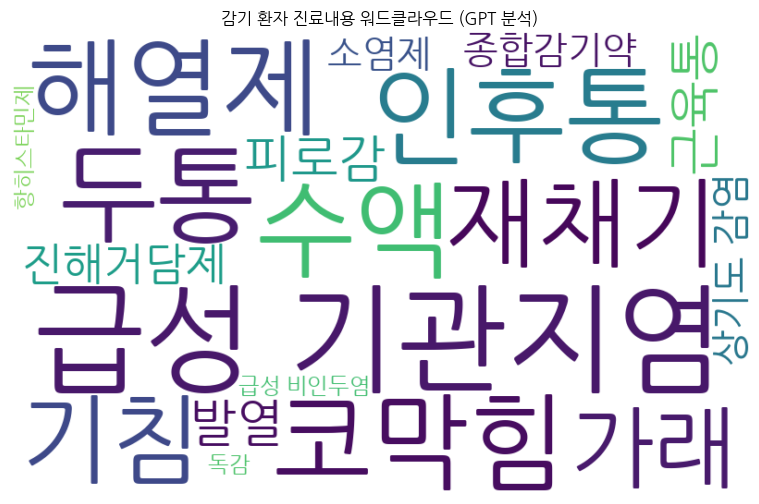

In [9]:
import os
from openai import OpenAI
import json
from wordcloud import WordCloud
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
# 1) 데이터 불러오기
df = pd.read_csv("감기환자_진료데이터.csv")
text = " ".join(df["진료내용"].tolist())

# 2) GPT에게 단어 추출 + 빈도수 세기를 통째로 시키기
prompt = f"""다음은 감기 환자 진료 기록 텍스트야.

{text}

이 텍스트에서 의미 있는 핵심 단어(증상, 질병, 처방 등)를 뽑아 빈도수를 세줘.
조사나 흔한 단어는 제외하고, 아래 JSON 형식으로만 답해줘. 다른 말은 붙이지 마.

{{"단어1": 횟수, "단어2": 횟수, ...}}"""

res = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
)

# 3) GPT 답변(JSON)을 파이썬 딕셔너리로 변환
answer = res.choices[0].message.content
answer = answer.replace("```json", "").replace("```", "").strip()
freq = json.loads(answer)

print("[GPT가 뽑은 단어 빈도]")
for word, cnt in sorted(freq.items(), key=lambda x: -x[1]):
    print(f"  {word}: {cnt}회")

# 4) GPT가 준 빈도수로 워드클라우드 그리기
wc = WordCloud(
    font_path="/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    background_color="white",
    width=800,
    height=500,
).generate_from_frequencies(freq)

plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("감기 환자 진료내용 워드클라우드 (GPT 분석)")
plt.show()